In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import COREEnsbl, Univariate, CovMatrix, COREObser, MagScObs, COREModel, COREParticleFilter, ObserVecNoise

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

In [2]:
# Set up model priors
model = COREModel([
    Univariate.uniform("longitude", -1.0, 1.0),
    Univariate.uniform("latitude", -0.25, 0.25),
    Univariate.uniform("inclination", -3.5, 3.14),
    Univariate.constant("distance_0", 20.0),
    Univariate.uniform("diameter_1au", 0.05, 0.35),
    Univariate.uniform("delta", 0.5, 1.0),

    Univariate.uniform("velocity", 700.0, 1500.0),
    Univariate.uniform("b_scale", 10.0, 30.0),
    Univariate.uniform("tau", -50.0, 0.0),
    Univariate.constant("sw_velocity", 400.0),
    Univariate.constant("sw_gamma", 1.0),
])

arr = np.array([
    [-3.13531505, -13.98423491, -6.64658269],
    [-3.38360946, -15.34720671, -1.71139834],
    [-4.21540068, -13.93568105, 4.73878965],
    [-5.41469694, -13.9772912, 4.14112123],
    [-4.30711573, -12.61217154, 5.78382821],
])

# set up observation scobs
scobs = MagScObs(
    # time stamps
    [3.5 * 24.0 * 3600.0 + 2.0 * 3600.0 * i for i in range(len(arr))],

    # sc position
    [[1.0, 0.0, 0.0] for _ in range(len(arr))],

    # data
    arr
)

pf_abc = model.new_pf(scobs, 2048, 44, simulation_time_limit=5, max_attempts=2500, simulation_ensemble_size_factor=8, max_iterations=5, error_quantile=0.35)
pf_abc.mag_initialize_rmse(1.0)
particles_initial = pf_abc.particles()
noise_model = ObserVecNoise.gaussian(1.0)
result_abc = np.array(pf_abc.mag_abc_rmse(noise_model))
particles_abc = pf_abc.particles()

INFO mod.rs:302 2025-07-24 10:22:27,574 pf_initialize_data
	KL delta: n/a | eps: 0.614 -- 0.676 -- 0.781
	ran 1.311M evaluations in 0.07 sec
INFO abc.rs:182 2025-07-24 10:22:27,576 pf_abc_loop starting, maximum 5 iterations
INFO abc.rs:125 2025-07-24 10:22:27,632 pf_abc_iter
	KL delta: 1.841 | eps: 0.454 -- 0.499 -- 0.539
	ran 0.328M evaluations in 0.06 sec
	effective sample size = 1094.6 / 2048
INFO abc.rs:125 2025-07-24 10:22:27,701 pf_abc_iter
	KL delta: 1.525 | eps: 0.366 -- 0.393 -- 0.418
	ran 0.410M evaluations in 0.07 sec
	effective sample size = 1292.7 / 2048
INFO abc.rs:125 2025-07-24 10:22:27,800 pf_abc_iter
	KL delta: 0.855 | eps: 0.310 -- 0.327 -- 0.345
	ran 0.655M evaluations in 0.10 sec
	effective sample size = 1236.8 / 2048
INFO abc.rs:125 2025-07-24 10:22:27,954 pf_abc_iter
	KL delta: 1.175 | eps: 0.267 -- 0.282 -- 0.293
	ran 1.147M evaluations in 0.15 sec
	effective sample size = 1380.4 / 2048
INFO abc.rs:125 2025-07-24 10:22:28,225 pf_abc_iter
	KL delta: 0.830 | eps: 

INFO mod.rs:302 2025-07-24 10:22:28,307 pf_initialize_data
	KL delta: n/a | eps: 0.619 -- 0.720 -- 0.826
	ran 1.393M evaluations in 0.08 sec
INFO dev.rs:144 2025-07-24 10:22:28,311 diff_ev_iter
	eps: 0.619 -- 0.720 -- 0.826
	ran 0.010M evaluations in 0.00 sec
	mutated = 0 / 2048
INFO dev.rs:144 2025-07-24 10:22:28,313 diff_ev_iter
	eps: 0.619 -- 0.720 -- 0.826
	ran 0.010M evaluations in 0.00 sec
	mutated = 0 / 2048
INFO dev.rs:144 2025-07-24 10:22:28,316 diff_ev_iter
	eps: 0.619 -- 0.720 -- 0.826
	ran 0.010M evaluations in 0.00 sec
	mutated = 487 / 2048
INFO dev.rs:144 2025-07-24 10:22:28,318 diff_ev_iter
	eps: 0.599 -- 0.666 -- 0.774
	ran 0.010M evaluations in 0.00 sec
	mutated = 1249 / 2048
INFO dev.rs:144 2025-07-24 10:22:28,320 diff_ev_iter
	eps: 0.599 -- 0.666 -- 0.774
	ran 0.010M evaluations in 0.00 sec
	mutated = 0 / 2048
INFO dev.rs:144 2025-07-24 10:22:28,323 diff_ev_iter
	eps: 0.599 -- 0.666 -- 0.774
	ran 0.010M evaluations in 0.00 sec
	mutated = 576 / 2048
INFO dev.rs:144 20

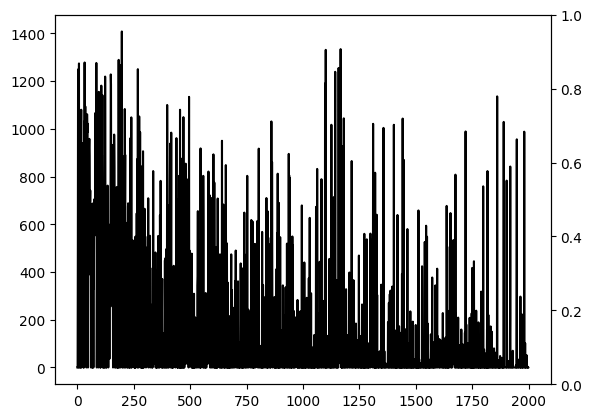

In [3]:
pf_dev = model.new_pf(scobs, 2048, 42, simulation_time_limit=5, simulation_ensemble_size_factor=8, max_iterations=8)
pf_dev.mag_initialize_rmse(1.0)
result_dev = np.array(pf_dev.mag_dev_rmse(2000, 0.1, 0.8))
particles_dev = pf_dev.particles()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_dev, color="k")
plt.show()

dev_min = pf_dev.particles()[0][np.argmin(pf_dev.errors())]

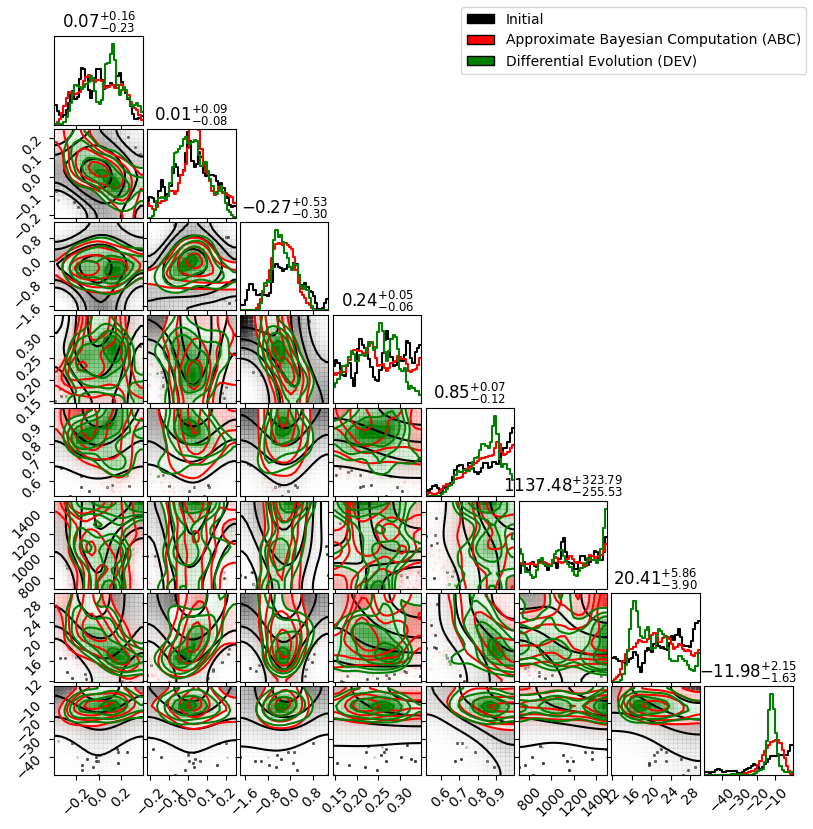

In [4]:
autorange = np.array([np.min(particles_initial[0], axis=0), np.max(particles_initial[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_initial[0].T[autoflag].T, 
              weights=particles_initial[1], color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev[0].T[autoflag].T, 
              weights=particles_dev[1], color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()

In [5]:
for i in np.array(list(range(4, 40)))[::-1] / 4:
    mat = np.diag([float(i) for _ in range(len(scobs))])
    covm = CovMatrix(mat)

    pf_abc.mag_sir_iter_mvllh(covm)
    pf_dev.mag_sir_iter_mvllh(covm)

pf_abc.mag_sir_iter_mvllh(covm)
pf_dev.mag_sir_iter_mvllh(covm)

pf_abc.mag_sir_iter_mvllh(covm)
pf_dev.mag_sir_iter_mvllh(covm)

particles_abc_sir = pf_abc.particles()
particles_dev_sir = pf_dev.particles()

INFO sir.rs:110 2025-07-24 10:22:34,508 pf_sir_iter interim ess = 315.67772633204135
INFO sir.rs:169 2025-07-24 10:22:34,517 pf_sir_iter
	KL delta: 7.801 
	ran 0.082M evaluations in 0.17 sec
	unique samples = 693 / 2048
INFO sir.rs:110 2025-07-24 10:22:34,673 pf_sir_iter interim ess = 18.799136755112972
INFO sir.rs:169 2025-07-24 10:22:34,680 pf_sir_iter
	KL delta: 12.099 
	ran 0.082M evaluations in 0.16 sec
	unique samples = 625 / 2048
INFO sir.rs:110 2025-07-24 10:22:34,836 pf_sir_iter interim ess = 191.49325458426492
INFO sir.rs:169 2025-07-24 10:22:34,843 pf_sir_iter
	KL delta: 8.099 
	ran 0.082M evaluations in 0.16 sec
	unique samples = 663 / 2048
INFO sir.rs:110 2025-07-24 10:22:35,004 pf_sir_iter interim ess = 48.66763534673619
INFO sir.rs:169 2025-07-24 10:22:35,012 pf_sir_iter
	KL delta: 9.342 
	ran 0.082M evaluations in 0.17 sec
	unique samples = 585 / 2048
INFO sir.rs:110 2025-07-24 10:22:35,175 pf_sir_iter interim ess = 168.1414418393318
INFO sir.rs:169 2025-07-24 10:22:35,

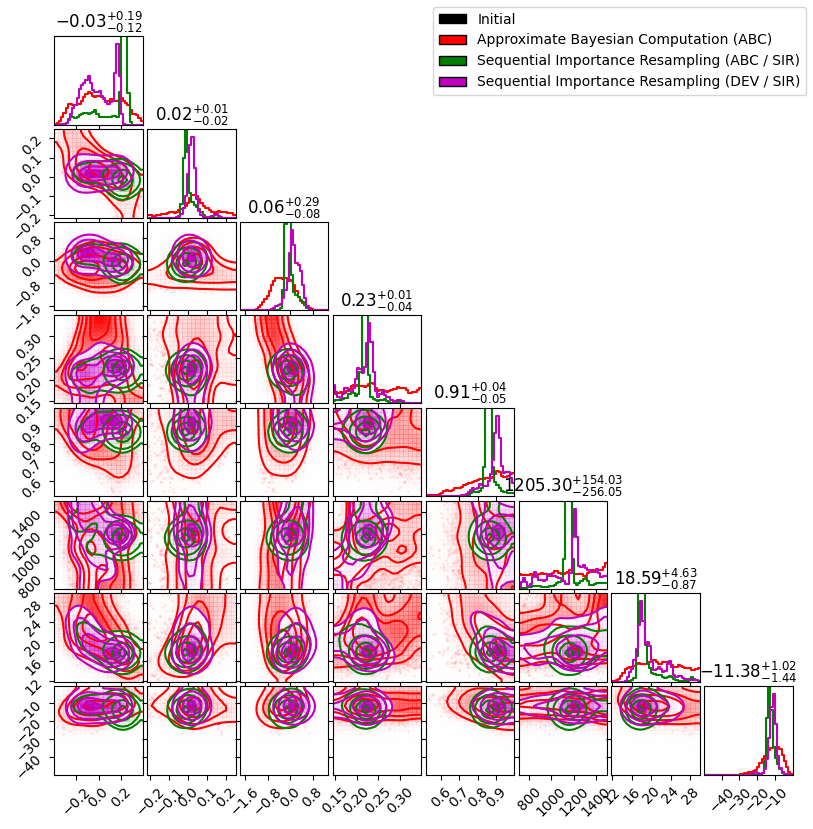

In [6]:
autorange = np.array([np.min(particles_initial[0], axis=0), np.max(particles_initial[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_abc_sir[0].T[autoflag].T, 
              weights=particles_abc_sir[1], color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev_sir[0].T[autoflag].T, 
              weights=particles_dev_sir[1], color='m',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Sequential Importance Resampling (ABC / SIR)"),
    Patch(facecolor='m', edgecolor='k', label="Sequential Importance Resampling (DEV / SIR)"),
], loc='upper right')
plt.show()